# Metric-Degree Sequence and Polynomils of Stnadard Graphs
## Computational graph theory project-2
This notebook develops general computational methods for calculating metric-degree sequences and metric-degree polynomials of connected graphs.
For a vertex \(v\)of a connected graph \(G\)
$$
d_i(v)=|\{u\in V(G):d(u,v)=i\}|,
$$

where \(d(u,v)\) denotes the shortest-path distance between vertices
\(u\) and \(v\).

The metric-degree sequence of \(v\) is

$$
\mathrm{MDS}(v)=
(d_0(v),d_1(v),\ldots,d_{\mathrm{ecc}(v)}(v)).
$$

The objective of this notebook is to develop reusable Python functions
for computing these quantities and to apply them to several standard
families of graphs.

### Graph families considered

- Path graphs \(P_n\)
- Cycle graphs \(C_n\)
- Complete graphs \(K_n\)
- Complete bipartite graphs \(K_{m,n}\)
- Star graphs \(K_{1,n}\)

The computational results will be compared with their expected
theoretical properties.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter


## 1. Understanding Metric-Degree Sequences Computationally

We first consider a simple path graph \(P_5\).

A path graph provides a useful introductory example because vertices
at different positions have different distance distributions. This
allows us to observe how the metric-degree sequence depends on the
location of a vertex within a graph.

In [2]:
P5 = nx.path_graph(5)
print("vertices:", list(P5.nodes()))
print("Eddges:",list(P5.edges()))

vertices: [0, 1, 2, 3, 4]
Eddges: [(0, 1), (1, 2), (2, 3), (3, 4)]


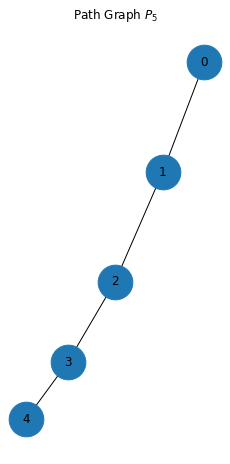

In [3]:
# 1. Create plotting area
plt.figure(figsize=(3, 6))

# 2. Calculate positions of vertices
pos = nx.spring_layout(P5, seed=42)

# 3. Draw the graph
nx.draw(
    P5,
    pos,
    with_labels=True,
    node_size=1200,
    font_size=12
)

# 4. Add title
plt.title("Path Graph $P_5$")

# 5. Display it
plt.show()



### Distances from an End Vertex

Consider vertex \(0\) of the path graph \(P_5\).

The distances from vertex \(0\) to the other vertices are

$$
d(0,0)=0,\quad
d(0,1)=1,\quad
d(0,2)=2,\quad
d(0,3)=3,\quad
d(0,4)=4.
$$

Therefore, there is exactly one vertex at each distance \(0,1,2,3,4\).
The metric-degree sequence of vertex \(0\) is consequently

$$
(1,1,1,1,1).
$$

In [5]:
distances_from_0 = nx.single_source_shortest_path_length(P5,0)
print(distances_from_0)

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4}


In [6]:
distances_from_2 = nx.single_source_shortest_path_length(P5,2)
print(distances_from_2)

{2: 0, 1: 1, 3: 1, 0: 2, 4: 2}


In [12]:
distance_counts = Counter(distances_from_2.values())
print(distance_counts)

Counter({1: 2, 2: 2, 0: 1})


## 2. General Metric-Degree Sequence Function

We now combine the previous steps into a reusable function.

For a connected graph \(G\) and a chosen vertex \(v\), the function will:

1. calculate shortest-path distances from \(v\) to all vertices;
2. count how many vertices occur at each distance;
3. return the metric-degree sequence

$$
(d_0(v),d_1(v),\ldots,d_{\mathrm{ecc}(v)}(v)).
$$

In [21]:
def metric_degree_sequence(G, vertex):
    distances = nx.single_source_shortest_path_length(G,vertex)
    counts = Counter(distances.values())
    eccentricity = max(distances.values())
    sequence=[
        counts.get(i,0)
        for i in range(eccentricity+1)
    ]
    return sequence
    

In [22]:
print("metricdegree:", metric_degree_sequence(P5,0))

metricdegree: [1, 1, 1, 1, 1]


In [23]:
print("MDS of vertex 0:", metric_degree_sequence(P5, 0))
print("MDS of vertex 2:", metric_degree_sequence(P5, 2))

MDS of vertex 0: [1, 1, 1, 1, 1]
MDS of vertex 2: [1, 2, 2]


In [24]:
for vertex in P5.nodes():
    print(
        f"Vertex {vertex}:",
        metric_degree_sequence(P5, vertex)
    )


Vertex 0: [1, 1, 1, 1, 1]
Vertex 1: [1, 2, 1, 1]
Vertex 2: [1, 2, 2]
Vertex 3: [1, 2, 1, 1]
Vertex 4: [1, 1, 1, 1, 1]


In [26]:
all_mds = {}
for vertex in P5.nodes():
    all_mds[vertex] = metric_degree_sequence(P5,vertex)
all_mds

{0: [1, 1, 1, 1, 1],
 1: [1, 2, 1, 1],
 2: [1, 2, 2],
 3: [1, 2, 1, 1],
 4: [1, 1, 1, 1, 1]}

## 3. Metric-Degree Polynomial

For a connected graph \(G\), the metric-degree polynomial is defined by

$$
N(G,x)
=
\sum_{i=0}^{\mathrm{diam}(G)}
\left(
\sum_{v\in V(G)} d_i(v)
\right)x^i.
$$

For each distance \(i\), we therefore add the \(i\)-th metric-degree
over all vertices of the graph.

If a vertex has eccentricity smaller than \(i\), its contribution to
\(d_i(v)\) is taken as zero.

In [28]:
diameter= nx.diameter(P5)
print("diameter of P5:", diameter)


diameter of P5: 4


In [29]:
coefficients =[]
for i in range(diameter+1):
    total = 0
    for vertex in P5.nodes():
        sequence= all_mds[vertex]
        if i< len(sequence):
            total+=sequence[i]
    coefficients.append(total)
print("polynomia coefficient:", coefficients)

polynomia coefficient: [5, 8, 6, 4, 2]


In [37]:
def metric_degree_polynomial_coefficients(G):
    """
    Compute coefficients of the metric-degree polynomial of a connected graph.
    """

    all_sequences = {
        vertex: metric_degree_sequence(G, vertex)
        for vertex in G.nodes()
    }

    diameter = nx.diameter(G)

    coefficients = []

    for i in range(diameter + 1):
        total = 0

        for vertex in G.nodes():
            sequence = all_sequences[vertex]

            if i < len(sequence):
                total += sequence[i]

        coefficients.append(total)

    return coefficients

In [38]:
metric_degree_polynomial_coefficients(P5)

[5, 8, 6, 4, 2]

In [41]:
metric_degree_polynomial_coefficients(nx.cycle_graph(6))

[6, 12, 12, 6]

## 4. Readable Form of the Metric-Degree Polynomial

The previous function returns the coefficients of the metric-degree
polynomial as a Python list.

For example, for \(P_5\),

$$
[5,8,6,4,2]
$$

represents

$$
N(P_5,x)=5+8x+6x^2+4x^3+2x^4.
$$

We now define a function that converts the coefficient list into a
human-readable polynomial expression.

In [42]:
def format_polynomial(coefficients):
    terms = []

    for i, coefficient in enumerate(coefficients):

        if coefficient == 0:
            continue

        if i == 0:
            term = f"{coefficient}"

        elif i == 1:
            term = f"{coefficient}x"

        else:
            term = f"{coefficient}x^{i}"

        terms.append(term)

    return " + ".join(terms)

In [43]:
coefficients_P5 = metric_degree_polynomial_coefficients(P5)

print(format_polynomial(coefficients_P5))

5 + 8x + 6x^2 + 4x^3 + 2x^4


In [48]:
P6 = nx.path_graph(6)
metric_degree_polynomial_coefficients(nx.path_graph(6))
coefficients_P6 = metric_degree_polynomial_coefficients(P6)
print(format_polynomial(coefficients_P6))

6 + 10x + 8x^2 + 6x^3 + 4x^4 + 2x^5


## 5. Metric-Degree Analysis of Cycle Graphs

We now apply the general metric-degree functions to cycle graphs.

A cycle graph \(C_n\) consists of \(n\) vertices arranged in a closed
cycle. Each vertex has degree 2.

Unlike a path graph, a cycle graph has no end vertices. Its symmetry
implies that every vertex has the same distance distribution and hence
the same metric-degree sequence.

We begin with \(C_5\).

In [49]:
C5 = nx.cycle_graph(5)

print("Vertices:", list(C5.nodes()))
print("Edges:", list(C5.edges()))

Vertices: [0, 1, 2, 3, 4]
Edges: [(0, 1), (0, 4), (1, 2), (2, 3), (3, 4)]


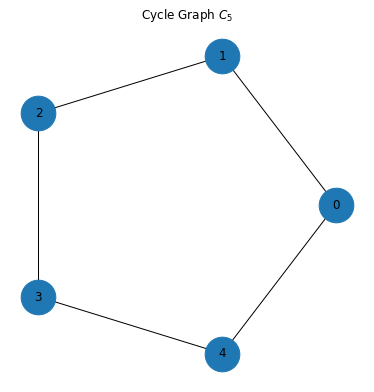

In [50]:
plt.figure(figsize=(5, 5))

pos = nx.circular_layout(C5)

nx.draw(
    C5,
    pos,
    with_labels=True,
    node_size=1200,
    font_size=12
)

plt.title("Cycle Graph $C_5$")
plt.show()

In [51]:
for vertex in C5.nodes():
    print(
        f"Vertex {vertex}:",
        metric_degree_sequence(C5, vertex)
    )

Vertex 0: [1, 2, 2]
Vertex 1: [1, 2, 2]
Vertex 2: [1, 2, 2]
Vertex 3: [1, 2, 2]
Vertex 4: [1, 2, 2]


In [54]:
def metric_degree_polynomial(G):
    coefficients = metric_degree_polynomial_coefficients(G)
    return format_polynomial(coefficients)

In [55]:
coefficients_C5 = metric_degree_polynomial_coefficients(C5)

print("Coefficients:", coefficients_C5)
print("N(C5, x) =", metric_degree_polynomial(C5))

Coefficients: [5, 10, 10]
N(C5, x) = 5 + 10x + 10x^2


In [56]:
for n in range(3, 9):
    Cn = nx.cycle_graph(n)

    print(
        f"C_{n}:",
        metric_degree_polynomial(Cn)
    )

C_3: 3 + 6x
C_4: 4 + 8x + 4x^2
C_5: 5 + 10x + 10x^2
C_6: 6 + 12x + 12x^2 + 6x^3
C_7: 7 + 14x + 14x^2 + 14x^3
C_8: 8 + 16x + 16x^2 + 16x^3 + 8x^4


### Odd and Even Cycle Graphs

The computational results reveal a clear difference between the
metric-degree structures of odd and even cycle graphs.

#### Odd Cycles

Consider an odd cycle

$$
C_{2k+1}.
$$

From any vertex, there are two vertices at each distance

$$
1,2,\ldots,k.
$$

Therefore, every vertex has the metric-degree sequence

$$
(1,2,2,\ldots,2).
$$

Since the graph contains \(2k+1\) vertices, summing the metric-degree
values over all vertices gives the metric-degree polynomial

$$
N(C_{2k+1},x)
=
(2k+1)
+
2(2k+1)
\left(
x+x^2+\cdots+x^k
\right).
$$

For example, for \(C_5\), we have \(k=2\), and hence

$$
N(C_5,x)
=
5+10x+10x^2.
$$

#### Even Cycles

Now consider an even cycle

$$
C_{2k}.
$$

From any vertex, there are two vertices at each distance

$$
1,2,\ldots,k-1,
$$

but there is only one vertex at the maximum distance \(k\). This is the
vertex directly opposite the selected vertex in the cycle.

Therefore, every vertex has the metric-degree sequence

$$
(1,2,2,\ldots,2,1).
$$

Since \(C_{2k}\) contains \(2k\) vertices, its metric-degree polynomial is

$$
N(C_{2k},x)
=
2k
+
4k
\left(
x+x^2+\cdots+x^{k-1}
\right)
+
2kx^k.
$$

For example, for \(C_6\), where \(k=3\),

$$
N(C_6,x)
=
6+12x+12x^2+6x^3.
$$

### Computational Observation

The Python calculations for several cycle graphs agree with these
theoretical patterns. Odd cycles have two vertices at every positive
distance from a selected vertex, whereas even cycles have only one
vertex at the maximum distance.

This illustrates how computational experiments can be used to identify
a pattern, formulate a general expression, and then compare the
computational result with the mathematical structure of the graph.

## 6. Metric-Degree Analysis of Complete Graphs

A complete graph \(K_n\) is a graph in which every pair of distinct
vertices is connected by an edge.

Therefore, every vertex is adjacent to all other \(n-1\) vertices.

For any vertex \(v\in V(K_n)\),

$$
d_0(v)=1
$$

and

$$
d_1(v)=n-1.
$$

Since every other vertex can be reached directly by one edge, the
diameter of \(K_n\) is 1 for \(n\geq2\).

Thus, the metric-degree sequence of every vertex is expected to be

$$
(1,n-1).
$$

We now verify this computationally.

In [57]:
K5 = nx.complete_graph(5)

print("Vertices:", list(K5.nodes()))
print("Edges:", list(K5.edges()))

Vertices: [0, 1, 2, 3, 4]
Edges: [(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]


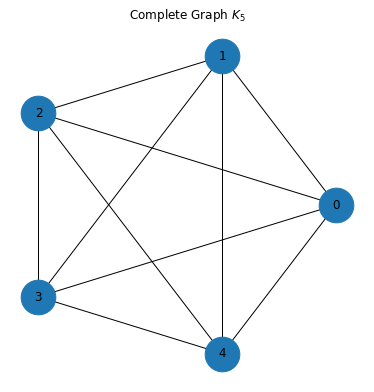

In [58]:
plt.figure(figsize=(5, 5))

pos = nx.circular_layout(K5)

nx.draw(
    K5,
    pos,
    with_labels=True,
    node_size=1200,
    font_size=12
)

plt.title("Complete Graph $K_5$")
plt.show()

In [59]:
for vertex in K5.nodes():
    print(
        f"Vertex {vertex}:",
        metric_degree_sequence(K5, vertex)
    )

Vertex 0: [1, 4]
Vertex 1: [1, 4]
Vertex 2: [1, 4]
Vertex 3: [1, 4]
Vertex 4: [1, 4]


In [60]:
coefficients_K5 = metric_degree_polynomial_coefficients(K5)

print("Coefficients:", coefficients_K5)
print("N(K5, x) =", metric_degree_polynomial(K5))

Coefficients: [5, 20]
N(K5, x) = 5 + 20x


In [61]:
for n in range(2, 8):
    Kn = nx.complete_graph(n)

    print(
        f"K_{n}:",
        metric_degree_polynomial(Kn)
    )

K_2: 2 + 2x
K_3: 3 + 6x
K_4: 4 + 12x
K_5: 5 + 20x
K_6: 6 + 30x
K_7: 7 + 42x


### General Metric-Degree Polynomial of \(K_n\)

The computational results suggest the general expression

$$
N(K_n,x)=n+n(n-1)x.
$$

This can be derived directly from the structure of the complete graph.

Every vertex \(v\) has metric-degree sequence

$$
(1,n-1),
$$

because the vertex itself is at distance 0 and all other \(n-1\)
vertices are directly adjacent to it.

Since \(K_n\) contains \(n\) vertices, summing these values over all
vertices gives

$$
\sum_{v\in V(K_n)}d_0(v)=n
$$

and

$$
\sum_{v\in V(K_n)}d_1(v)=n(n-1).
$$

Therefore,

$$
N(K_n,x)=n+n(n-1)x.
$$

The computational results for several values of \(n\) agree with this
general expression.

## 7. Metric-Degree Analysis of Complete Bipartite Graphs

A complete bipartite graph \(K_{m,n}\) has its vertex set divided into
two disjoint partitions of sizes \(m\) and \(n\).

Every vertex in the first partition is adjacent to every vertex in the
second partition, while no two vertices within the same partition are
adjacent.

This structure produces two classes of vertices when \(m\neq n\).
Vertices belonging to different partitions can therefore have different
metric-degree sequences.

We begin with the complete bipartite graph \(K_{2,3}\).

Partition A        Partition B

    0  ─────────  2
     \            /
      \──────────3
     /            \
    1  ─────────  4

In [63]:
K23 = nx.complete_bipartite_graph(2, 3)

print("Vertices:", list(K23.nodes()))
print("Edges:", list(K23.edges()))

Vertices: [0, 1, 2, 3, 4]
Edges: [(0, 2), (0, 3), (0, 4), (1, 2), (1, 3), (1, 4)]


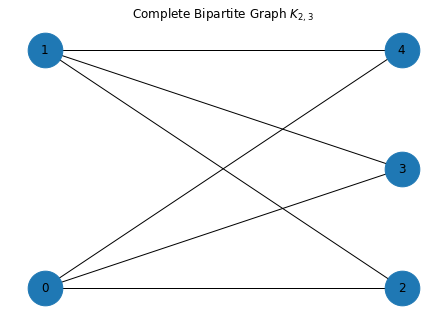

In [64]:
plt.figure(figsize=(6, 4))

pos = nx.bipartite_layout(K23, nodes=[0, 1])

nx.draw(
    K23,
    pos,
    with_labels=True,
    node_size=1200,
    font_size=12
)

plt.title("Complete Bipartite Graph $K_{2,3}$")
plt.show()

In [65]:
for vertex in K23.nodes():
    print(
        f"Vertex {vertex}:",
        metric_degree_sequence(K23, vertex)
    )

Vertex 0: [1, 3, 1]
Vertex 1: [1, 3, 1]
Vertex 2: [1, 2, 2]
Vertex 3: [1, 2, 2]
Vertex 4: [1, 2, 2]


In [66]:
coefficients_K23 = metric_degree_polynomial_coefficients(K23)

print("Coefficients:", coefficients_K23)
print("N(K23, x) =", metric_degree_polynomial(K23))

Coefficients: [5, 12, 8]
N(K23, x) = 5 + 12x + 8x^2


### General Metric-Degree Polynomial of \(K_{m,n}\)

The complete bipartite graph \(K_{m,n}\) contains two vertex
partitions of sizes \(m\) and \(n\).

A vertex belonging to the partition of size \(m\) has metric-degree
sequence

$$
(1,n,m-1),
$$

while a vertex belonging to the partition of size \(n\) has
metric-degree sequence

$$
(1,m,n-1).
$$

Thus, the graph contains two structural classes of vertices when
\(m\neq n\).

Summing the metric-degree values over all vertices gives

$$
\sum_{v\in V(G)}d_0(v)=m+n,
$$

$$
\sum_{v\in V(G)}d_1(v)=2mn,
$$

and

$$
\sum_{v\in V(G)}d_2(v)
=
m(m-1)+n(n-1).
$$

Therefore,

$$
N(K_{m,n},x)
=
(m+n)
+
2mnx
+
\left[m(m-1)+n(n-1)\right]x^2.
$$

For \(K_{2,3}\), this gives

$$
N(K_{2,3},x)
=
5+12x+8x^2,
$$

which agrees with the computational result.

## Conclusion

This notebook developed reusable computational methods for studying
metric-degree sequences and metric-degree polynomials of connected graphs.

The implementation was first demonstrated using path graphs and was then
applied to cycle graphs, complete graphs, and complete bipartite graphs.
The computational results were compared with theoretical expressions
derived from the structural properties of each graph family.

The examples illustrate several important features of metric-degree
analysis, including variation among vertices in path graphs, symmetry
in cycle and complete graphs, odd-even behaviour in cycles, and the
presence of distinct vertex classes in complete bipartite graphs.

The functions developed in this notebook provide a general framework
that can be extended to more structurally complex graphs, including
graphs arising from algebraic structures such as finite groups.